<a href="https://colab.research.google.com/github/Hernandez-Zachary/CPE311/blob/main/Hands_on_Activity_10_1_Data_Analysis_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/content/drive/MyDrive/CPE311 | Computational Thinking with Python/price_of_healthy_diet_clean.csv")
print(df.shape)
print(df.head())
print(df.describe())  # Note the ()
print(df.isnull().sum())  # Check missing values

(1379, 11)
   country_code  country  region  year  cost_healthy_diet_ppp_usd  \
0             8  Albania  Africa  2017                       3.04   
1             8  Albania  Africa  2018                       3.13   
2             8  Albania  Africa  2019                       3.32   
3             8  Albania  Africa  2020                       3.40   
4             8  Albania  Africa  2021                       3.49   

   annual_cost_healthy_diet_usd  cost_vegetables_ppp_usd  cost_fruits_ppp_usd  \
0                       1109.60                      NaN                  NaN   
1                       1142.45                      NaN                  NaN   
2                       1211.80                      NaN                  NaN   
3                       1241.00                      NaN                  NaN   
4                       1273.85                      0.6                 0.77   

   total_food_components_cost cost_category     data_quality  
0                       

### DATA CLEANING
---

In [ ]:
# Dropping dumplicates in the data set
df = df.drop_duplicates()


In [6]:
# Simplifying / Shortening column names
df.rename(columns={
    'country_code': 'cntry_code',
    'country': 'ctry',
    'cost_healthy_diet_ppp_usd': 'cost_hDiet',
    'annual_cost_healthy_diet_usd': 'ann_cost_hDiet',  # Fixed typo
    'cost_vegetables_ppp_usd': 'veg_cost',
    'cost_fruits_ppp_usd': 'fruits_cost',
    'total_food_components_cost': 'total_fComp_cost',  # Fixed typo
    'cost_category': 'category',
    'data_quality': 'dataQual'
}, inplace=True)

In [8]:
df_clean = df.dropna(subset=['cost_hDiet', 'ann_cost_hDiet'])

### Data Loading

        cntry_code         year   cost_hDiet  ann_cost_hDiet    veg_cost  \
count  1379.000000  1379.000000  1379.000000     1379.000000  166.000000   
mean    420.996374  2020.490210     3.677411     1342.255076    0.762711   
std     248.244476     2.293522     0.899691      328.387152    0.293952   
min       8.000000  2017.000000     1.700000      620.500000    0.210000   
25%     203.000000  2018.000000     3.010000     1098.650000    0.532500   
50%     417.000000  2020.000000     3.550000     1295.750000    0.740000   
75%     642.500000  2022.000000     4.205000     1534.825000    0.937500   
max     894.000000  2024.000000     8.390000     3062.350000    1.690000   

       fruits_cost  total_fComp_cost  
count   166.000000        166.000000  
mean      0.675361          1.438072  
std       0.299848          0.496151  
min       0.170000          0.380000  
25%       0.450000          1.142500  
50%       0.660000          1.440000  
75%       0.827500          1.667500  
max

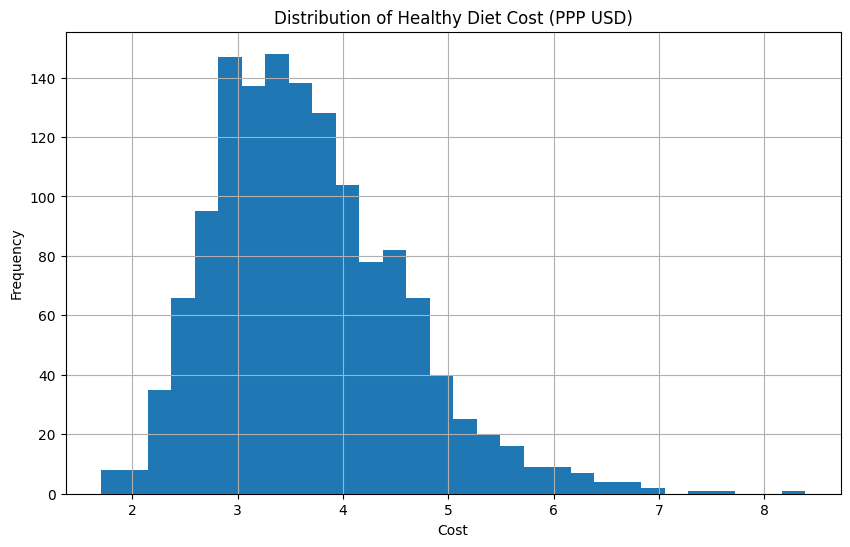

In [9]:
# Summary statistics
print(df_clean.describe())

# Group by region/year for insights
print(df_clean.groupby('region')['cost_hDiet'].agg(['mean', 'median', 'std']))

# Visualize cost distribution
plt.figure(figsize=(10, 6))
df_clean['cost_hDiet'].hist(bins=30)
plt.title('Distribution of Healthy Diet Cost (PPP USD)')
plt.xlabel('Cost')
plt.ylabel('Frequency')
plt.show()

Correlation Matrix:
                  cost_hDiet  ann_cost_hDiet  veg_cost  fruits_cost  \
cost_hDiet          1.000000        1.000000  0.620343     0.528945   
ann_cost_hDiet      1.000000        1.000000  0.620343     0.528945   
veg_cost            0.620343        0.620343  1.000000     0.396238   
fruits_cost         0.528945        0.528945  0.396238     1.000000   
total_fComp_cost    0.687198        0.687198  0.831930     0.839105   
year                0.519331        0.519331       NaN          NaN   

                  total_fComp_cost      year  
cost_hDiet                0.687198  0.519331  
ann_cost_hDiet            0.687198  0.519331  
veg_cost                  0.831930       NaN  
fruits_cost               0.839105       NaN  
total_fComp_cost          1.000000       NaN  
year                           NaN  1.000000  


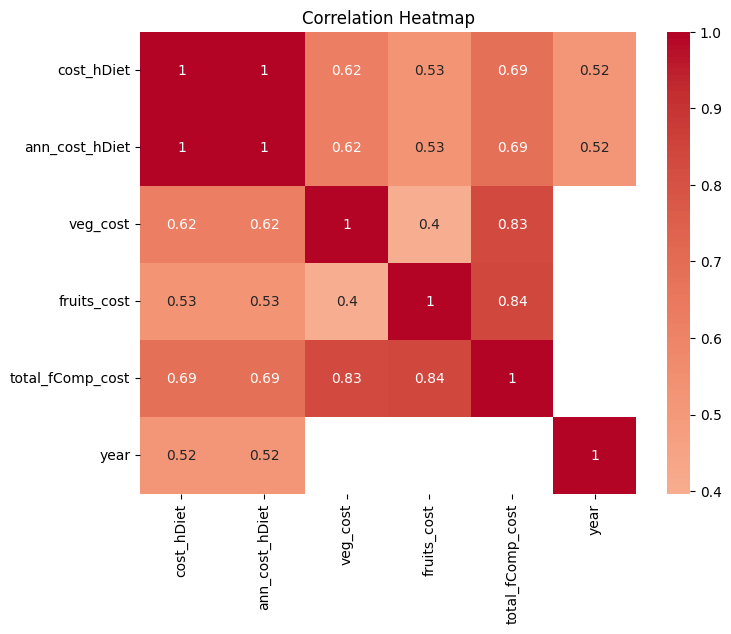

In [10]:
# Select numeric columns for correlation
numeric_cols = ['cost_hDiet', 'ann_cost_hDiet', 'veg_cost', 'fruits_cost', 'total_fComp_cost', 'year']
corr_matrix = df_clean[numeric_cols].corr()

print("Correlation Matrix:")
print(corr_matrix)

# Visualize with heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()